# Testing

In [7]:
#IMPORTS
import matplotlib.pyplot as plt
import scipy.io as sio
import pandas as pd
import numpy as np
from sklearn.decomposition import FastICA
from visulizacion import *
from evaluacion import *
from metricas import *
from preprocesamiento import *

#VARIABLES
fs=1000
window_size=200
salto=50

## Load data

In [8]:
mat=load_mat("C:/Users/34648/Desktop/Clases/4_GITT/TFG/OPENICPSR/TR2_postTMR_32chanEMG.mat")

## Preprocesing

In [9]:
#Preprocesado
emg = find_movement_rep(mat, "indexFlex", rep=1)[0]


emg = eliminar_continua(emg)
emg = eliminar_outiliers(emg, k=8)
emg = escalar_canales(emg, metodo="rms")



s1 = emg[:, 13]
s2 = emg[:, 18]

## Generacion señales

In [10]:
# Ejemplo: coger una repetición de un movimiento real
X1, key1 = find_movement_rep(mat, movement="HandOpen", rep=1)
X2, key2 = find_movement_rep(mat, movement="noMotion", rep=1)  # o otro movimiento

print("Señal 1 extraída de:", key1)
print("Señal 2 extraída de:", key2)

ch_s1 = 3
ch_s2 = 20

u1 = eliminar_continua(X1[:, ch_s1].astype(float))
u2_raw = eliminar_continua(X1[:, ch_s2].astype(float))  # también puedes cogerlo de otro movimiento

#Longitudes
N = min(len(u1), len(u2_raw))
u1 = u1[:N]
u2_raw = u2_raw[:N]
N = len(u1)
t = np.arange(N) / fs

m1 = np.zeros(N)
m2 = np.zeros(N)

# ejemplo por bloques de 0.5 s
bloque = int(0.2 * fs)
bloque = int(0.2 * fs)
bloque2 = int(0.2 * fs)
# patrón:
# 0: ninguno
# 1: solo s1
# 2: solo s2
# 3: ambos
patron = [0, 1, 2,1, 3, 2, 1, 2, 3, 0,2, 3,1]

for i, estado in enumerate(patron):
    a = i * bloque
    a2= i * bloque2
    b = min((i + 1) * bloque, N)
    b2= min((i + 1) * bloque2, N)
    if estado == 1:
        m1[a:b] = 1.0
    elif estado == 2:
        m2[a2:b2] = 1.0
    elif estado == 3:
        m1[a:b] = 1.0
        m2[a2:b2] = 1.0


#CONSTRUCCION DE SEÑALES

s1 = m1 * u1
s2 = m2 * u2_raw

#RETARDOS DE S2
tau_ms = 10
tau = int(fs * tau_ms / 1000)

s2_delayed = np.zeros_like(s2)

if tau < len(s2):
    s2_delayed[tau:] = s2[:-tau]

#MEZCLAS
beta = 0.4
noise_std = 0.6

rng = np.random.default_rng(0)
n1 = noise_std * rng.standard_normal(len(s1))
n2 = noise_std * rng.standard_normal(len(s1))

c1 = 1.0 * s1 + beta * s2_delayed + n1
c2 = 0.01 * s1 + 1.0 * s2 + n2

X_mix = np.column_stack([c1, c2])
S_true = np.column_stack([s1, s2_delayed])

Señal 1 extraída de: HandOpen_1.DAQ_DATA
Señal 2 extraída de: NoMotion_1.DAQ_DATA


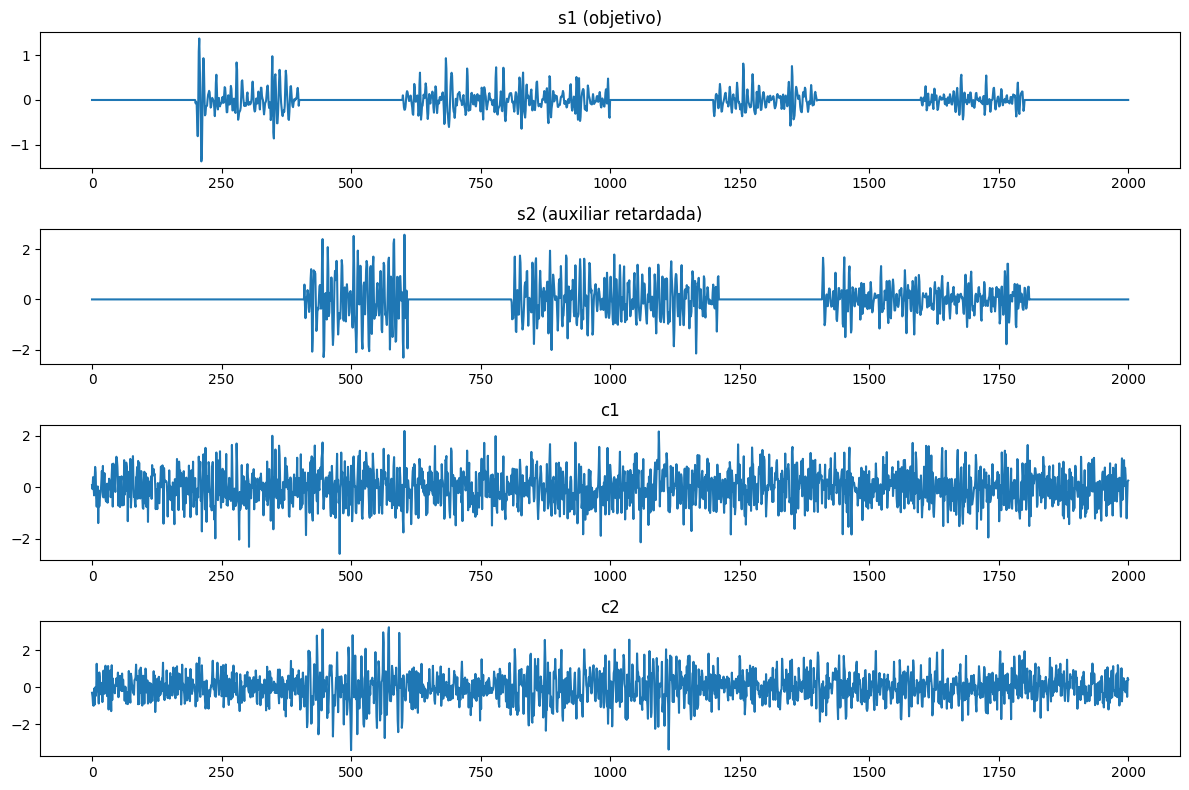

In [11]:
plt.figure(figsize=(12, 8))

plt.subplot(4, 1, 1)
plt.plot(s1)
plt.title("s1 (objetivo)")

plt.subplot(4, 1, 2)
plt.plot(s2_delayed)
plt.title("s2 (auxiliar retardada)")

plt.subplot(4, 1, 3)
plt.plot(c1)
plt.title("c1")

plt.subplot(4, 1, 4)
plt.plot(c2)
plt.title("c2")

plt.tight_layout()
plt.show()

## Test caso óptimo

- No ruido 
- $\tau =0 ms$

Matriz de mezcla A:
[[1.   0.7 ]
 [0.01 1.  ]]

=== Resultados ===
 method source     corr  corr_rms  rms_true  rms_est  rms_rel_error  rel_mae_rms_env
FastICA     s1 0.999858  0.999912  0.169247      1.0       4.908511         4.934630
FastICA     s2 0.999858  0.999905  0.513610      1.0       0.947002         0.960037
   SOBI     s1 0.999694  0.999810  0.169247      1.0       4.908511         4.946445
   SOBI     s2 0.999960  0.999974  0.513610      1.0       0.947002         0.954026

=== Comparación respecto a s1 ===
 method     corr  corr_rms  rms_true  rms_est  rms_rel_error  rel_mae_rms_env
FastICA 0.999858  0.999912  0.169247      1.0       4.908511         4.934630
   SOBI 0.999694  0.999810  0.169247      1.0       4.908511         4.946445


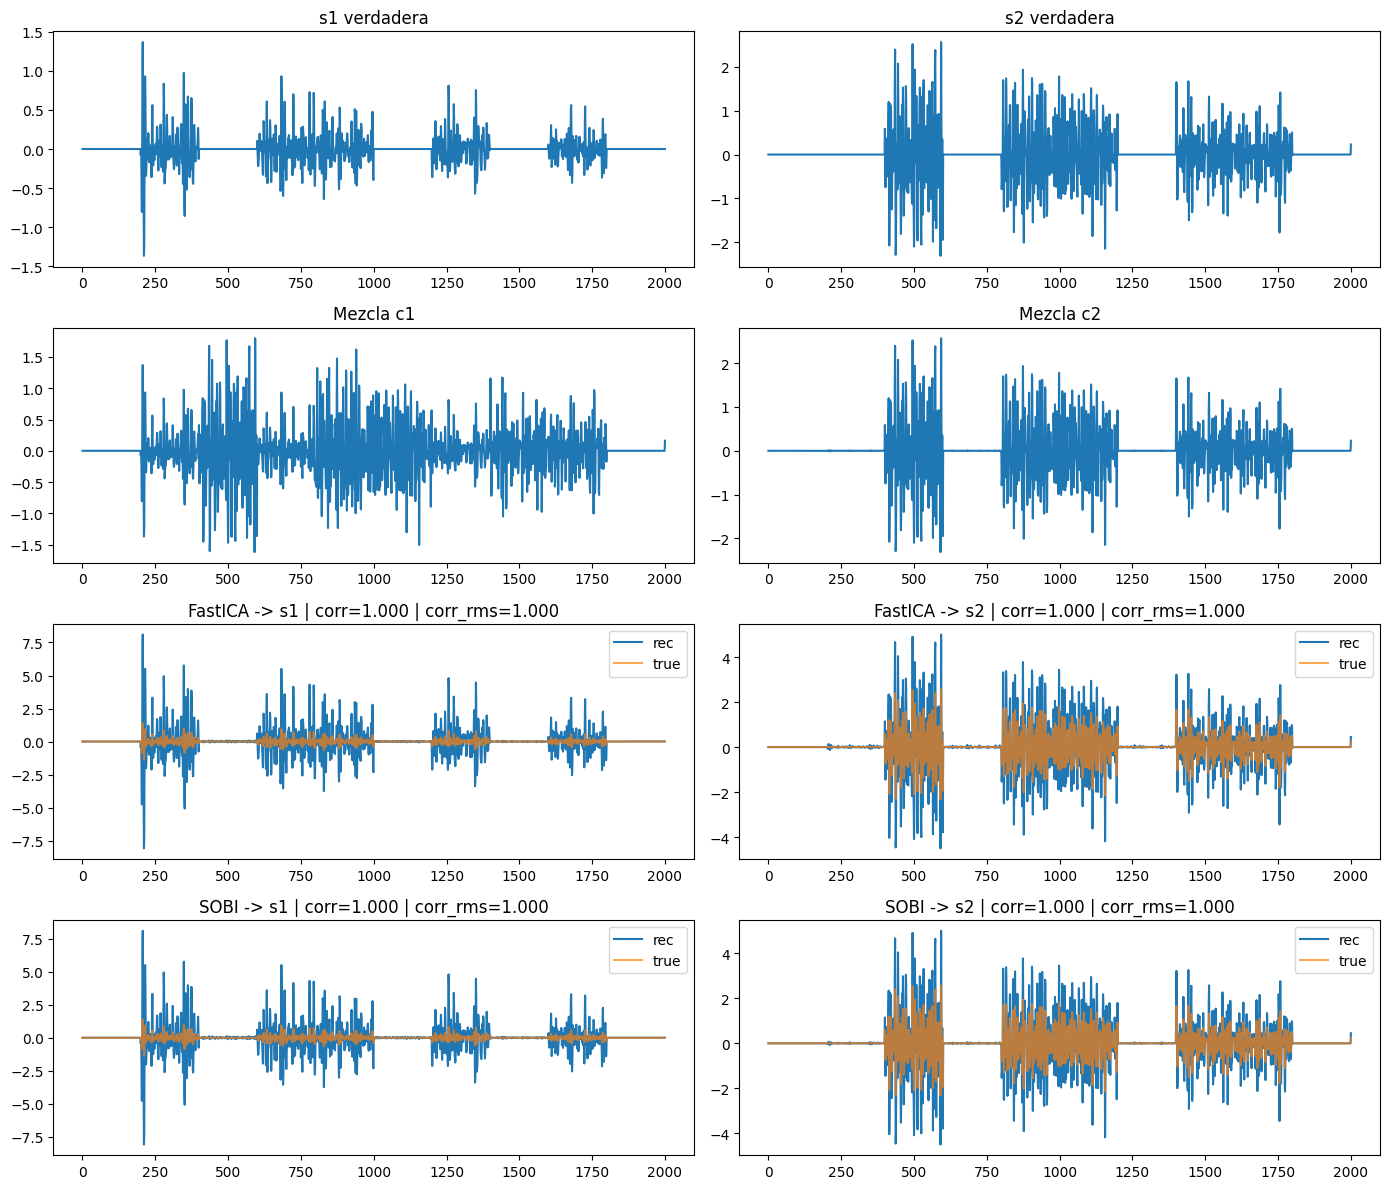

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.decomposition import FastICA

def center(X):
    return X - np.mean(X, axis=0, keepdims=True)


def whiten(X, eps=1e-12):
    """
    X: shape (N, m)
    devuelve:
      Xw: datos blanqueados
      whitening_mat
      dewhitening_mat
      mean_
    """
    X = np.asarray(X, dtype=float)
    mean_ = np.mean(X, axis=0, keepdims=True)
    Xc = X - mean_

    C = np.cov(Xc, rowvar=False)
    eigvals, eigvecs = np.linalg.eigh(C)

    idx = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    D_inv_sqrt = np.diag(1.0 / np.sqrt(eigvals + eps))
    D_sqrt = np.diag(np.sqrt(eigvals + eps))

    whitening_mat = eigvecs @ D_inv_sqrt @ eigvecs.T
    dewhitening_mat = eigvecs @ D_sqrt @ eigvecs.T

    Xw = Xc @ whitening_mat.T
    return Xw, whitening_mat, dewhitening_mat, mean_


#evaluate_method esta definido en evaluacion.py

s1 = np.asarray(s1).ravel().astype(float)
s2 = np.asarray(s2).ravel().astype(float)

N = min(len(s1), len(s2))
s1 = s1[:N]
s2 = s2[:N]

S_true = np.column_stack([s1, s2])

#PARAMETROS
fs = 1000
window_ms = 150
step_ms = 50

beta = 0.7
a11 = 1
a12 = beta
a21 = 0.01
a22 = 1.0
noise_std = 0.0
seed = 0

rng = np.random.default_rng(seed)
n = noise_std * rng.standard_normal((N, 2))

A = np.array([
    [a11, a12],
    [a21, a22]
])

X_clean = S_true @ A.T
X = X_clean + n

print("Matriz de mezcla A:")
print(A)


#FASTICA
S_fastica, W_fastica = run_fastica(X, n_components=2, random_state=0)
df_fastica, S_fastica_eval, env_fastica = evaluate_method(
    "FastICA", S_fastica, S_true,
    fs=fs, window_ms=window_ms, step_ms=step_ms
)

#SOBI
lags = [1, 2, 3, 5, 8, 12, 16, 20, 25, 30]
S_sobi, W_sobi = sobi(X, n_sources=2, delays=lags)
df_sobi, S_sobi_eval, env_sobi = evaluate_method(
    "SOBI", S_sobi, S_true,
    fs=fs, window_ms=window_ms, step_ms=step_ms
)


#GUARDAR RESULTADOS
df_results = pd.concat([df_fastica, df_sobi], ignore_index=True)

print("\n=== Resultados ===")
print(df_results.to_string(index=False))

#RESUMEN PARA S1
df_s1 = df_results[df_results["source"] == "s1"].copy()
print("\n=== Comparación respecto a s1 ===")
print(df_s1[[
    "method", "corr", "corr_rms", "rms_true", "rms_est",
    "rms_rel_error", "rel_mae_rms_env"
]].to_string(index=False))

###################################################
#Graficas
num_samples_plot = min(4000, N)
t = np.arange(num_samples_plot)

plt.figure(figsize=(14, 12))

plt.subplot(4, 2, 1)
plt.plot(t, s1[:num_samples_plot])
plt.title("s1 verdadera")

plt.subplot(4, 2, 2)
plt.plot(t, s2[:num_samples_plot])
plt.title("s2 verdadera")

plt.subplot(4, 2, 3)
plt.plot(t, X[:num_samples_plot, 0])
plt.title("Mezcla c1")

plt.subplot(4, 2, 4)
plt.plot(t, X[:num_samples_plot, 1])
plt.title("Mezcla c2")

plt.subplot(4, 2, 5)
plt.plot(t, S_fastica_eval[:num_samples_plot, 0], label="rec")
plt.plot(t, s1[:num_samples_plot], alpha=0.7, label="true")
plt.title(
    f"FastICA -> s1 | corr={safe_corr(S_fastica_eval[:,0], s1):.3f} | "
    f"corr_rms={env_fastica['s1']['corr_rms']:.3f}"
)
plt.legend()

plt.subplot(4, 2, 6)
plt.plot(t, S_fastica_eval[:num_samples_plot, 1], label="rec")
plt.plot(t, s2[:num_samples_plot], alpha=0.7, label="true")
plt.title(
    f"FastICA -> s2 | corr={safe_corr(S_fastica_eval[:,1], s2):.3f} | "
    f"corr_rms={env_fastica['s2']['corr_rms']:.3f}"
)
plt.legend()

plt.subplot(4, 2, 7)
plt.plot(t, S_sobi_eval[:num_samples_plot, 0], label="rec")
plt.plot(t, s1[:num_samples_plot], alpha=0.7, label="true")
plt.title(
    f"SOBI -> s1 | corr={safe_corr(S_sobi_eval[:,0], s1):.3f} | "
    f"corr_rms={env_sobi['s1']['corr_rms']:.3f}"
)
plt.legend()

plt.subplot(4, 2, 8)
plt.plot(t, S_sobi_eval[:num_samples_plot, 1], label="rec")
plt.plot(t, s2[:num_samples_plot], alpha=0.7, label="true")
plt.title(
    f"SOBI -> s2 | corr={safe_corr(S_sobi_eval[:,1], s2):.3f} | "
    f"corr_rms={env_sobi['s2']['corr_rms']:.3f}"
)
plt.legend()

plt.tight_layout()
plt.show()



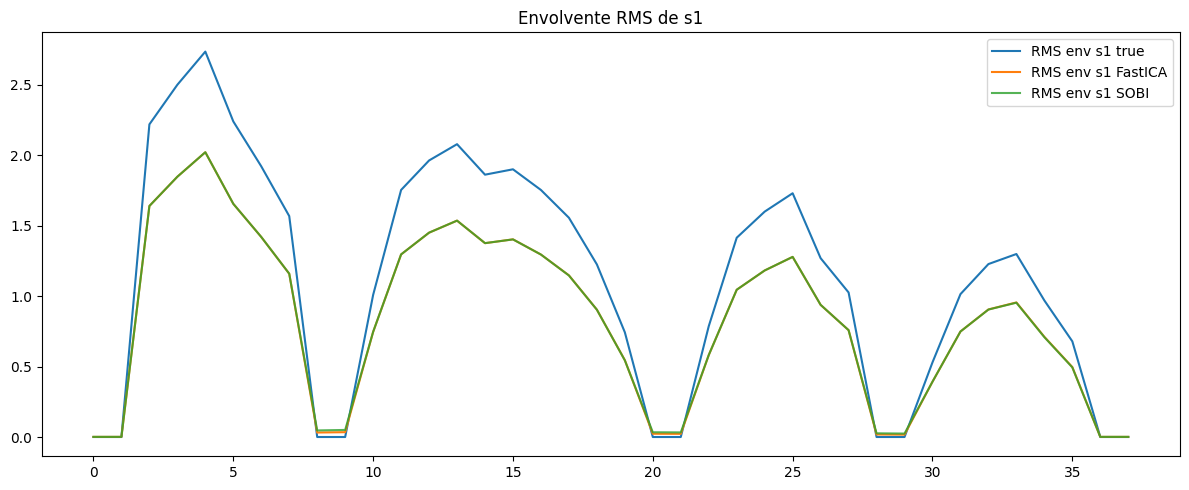

In [13]:
#Grafica de envolventes RMS
plt.figure(figsize=(12, 5))
plt.plot(8*env_fastica["s1"]["env_true"], label="RMS env s1 true")
plt.plot(env_fastica["s1"]["env_est"], label="RMS env s1 FastICA")
plt.plot(env_sobi["s1"]["env_est"], label="RMS env s1 SOBI", alpha=0.8)
plt.title("Envolvente RMS de s1")
plt.legend()
plt.tight_layout()
plt.show()